In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/cleaned_courses.csv")
df.head()

,institute_name,course_name,tutor,subject,course_type,learning_format,total_hours,price,price_per_hour,url
0,SmartMathPro,PACK คณิต ม.6 เทอม 1+2 + พิชิตคณิตพื้นฐาน ม.6 ...,พี่ปั้น SmartMathPro,คณิตศาสตร์,คอร์สแพ็กเกจ,วิดีโอ (ออนไลน์),143.0,5650.0,39.51,https://online.smartmathpro.com/product/e043/
1,SmartMathPro,PACK A-Level ไทย-สังคม (V.เต็ม),"อ.ขลุ่ย, ครูกอล์ฟ",ภาษาไทย-สังคมศึกษา,คอร์สแพ็กเกจ,วิดีโอ (ออนไลน์),121.0,3390.0,28.02,https://online.smartmathpro.com/product/p021/
2,SmartMathPro,PACK TPAT1 (ครบ 3 พาร์ต) + A-Level คณิต 1 (V.เ...,"พี่ปั้น SmartMathPro, อ.ขลุ่ย, พี่หมออู๋",แพ็กเกจเตรียมสอบแพทย์ (กสพท/TPAT1),คอร์สแพ็กเกจ,วิดีโอ (ออนไลน์),433.0,12350.0,28.52,https://online.smartmathpro.com/product/c029/
3,SmartMathPro,PACK TPAT3 (V.เต็ม) + A-Level คณิต 1 (V.เต็ม) ...,"พี่ปั้น SmartMathPro, อ.ขลุ่ย, พี่หนู, พี่ฟาร์...",แพ็กเกจเตรียมสอบวิศวะ (TPAT3),คอร์สแพ็กเกจ,วิดีโอ (ออนไลน์),628.0,21390.0,34.06,https://online.smartmathpro.com/product/r027/
4,SmartMathPro,PACK A-Level คณิต 2 (V.เต็ม) + ปรับพื้นคณิตพิช...,พี่ปั้น SmartMathPro,คณิตศาสตร์,คอร์สแพ็กเกจ,วิดีโอ (ออนไลน์),86.0,3350.0,38.95,https://online.smartmathpro.com/product/d048/


In [2]:
df.shape

(439, 10)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   institute_name   439 non-null    str    
 1   course_name      439 non-null    str    
 2   tutor            439 non-null    str    
 3   subject          439 non-null    str    
 4   course_type      439 non-null    str    
 5   learning_format  439 non-null    str    
 6   total_hours      439 non-null    float64
 7   price            439 non-null    float64
 8   price_per_hour   439 non-null    float64
 9   url              439 non-null    str    
dtypes: float64(3), str(7)
memory usage: 34.4 KB


In [13]:
# ==========================================
# ท่าที่ 2: ระเบิดแถวติวเตอร์ (Explode) สร้าง Dimension Table
# ==========================================
# สร้าง DataFrame ใหม่ที่เก็บแค่ ข้อมูลคอร์ส กับ ชื่อติวเตอร์
tutor_df = df[['institute_name', 'course_name', 'tutor']].copy()

# แปลง string ที่มีลูกน้ำ ให้กลายเป็น List แบบ Python -> ['พี่ปั้น', 'อ.ขลุ่ย']
tutor_df['tutor_list'] = tutor_df['tutor'].apply(lambda x: [t.strip() for t in str(x).split(',')])

# ใช้คำสั่งเทพของ Pandas: .explode() เพื่อระเบิด List ให้กลายเป็นแถวใหม่
df_tutors = tutor_df.explode('tutor_list')

# เปลี่ยนชื่อคอลัมน์ให้ดูง่ายขึ้น
df_tutors.rename(columns={'tutor_list': 'individual_tutor'}, inplace=True)
df_tutors.drop(columns=['tutor'], inplace=True) # ลบคอลัมน์เก่าทิ้ง

print("\n--- ตัวอย่างตารางติวเตอร์แบบแยกรายคน (Exploded) ---")
print(df_tutors.head(10))



--- ตัวอย่างตารางติวเตอร์แบบแยกรายคน (Exploded) ---
  institute_name                                        course_name  \
0   SmartMathPro  PACK คณิต ม.6 เทอม 1+2 + พิชิตคณิตพื้นฐาน ม.6 ...   
1   SmartMathPro                    PACK A-Level ไทย-สังคม (V.เต็ม)   
1   SmartMathPro                    PACK A-Level ไทย-สังคม (V.เต็ม)   
2   SmartMathPro  PACK TPAT1 (ครบ 3 พาร์ต) + A-Level คณิต 1 (V.เ...   
2   SmartMathPro  PACK TPAT1 (ครบ 3 พาร์ต) + A-Level คณิต 1 (V.เ...   
2   SmartMathPro  PACK TPAT1 (ครบ 3 พาร์ต) + A-Level คณิต 1 (V.เ...   
3   SmartMathPro  PACK TPAT3 (V.เต็ม) + A-Level คณิต 1 (V.เต็ม) ...   
3   SmartMathPro  PACK TPAT3 (V.เต็ม) + A-Level คณิต 1 (V.เต็ม) ...   
3   SmartMathPro  PACK TPAT3 (V.เต็ม) + A-Level คณิต 1 (V.เต็ม) ...   
3   SmartMathPro  PACK TPAT3 (V.เต็ม) + A-Level คณิต 1 (V.เต็ม) ...   

       individual_tutor  
0  พี่ปั้น SmartMathPro  
1               อ.ขลุ่ย  
1              ครูกอล์ฟ  
2  พี่ปั้น SmartMathPro  
2               อ.ขลุ่ย  
2        

In [7]:
print(df.info())
print("\n--- Summary Stats ---")
print(df.describe())
print("\n--- Value Counts for Categorical Columns ---")
print("Institutes:\n", df['institute_name'].value_counts().head())
print("\nSubjects:\n", df['subject'].value_counts().head(10))
print("\nCourse Types:\n", df['course_type'].value_counts().head())

<class 'pandas.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   institute_name   439 non-null    str    
 1   course_name      439 non-null    str    
 2   tutor            439 non-null    str    
 3   subject          439 non-null    str    
 4   course_type      439 non-null    str    
 5   learning_format  439 non-null    str    
 6   total_hours      439 non-null    float64
 7   price            439 non-null    float64
 8   price_per_hour   439 non-null    float64
 9   url              439 non-null    str    
dtypes: float64(3), str(7)
memory usage: 34.4 KB
None

--- Summary Stats ---
       total_hours         price  price_per_hour
count   439.000000    439.000000      439.000000
mean     84.843964   4291.410023       81.478405
std     131.070305   4915.741769       57.352463
min       4.000000    190.000000        0.000000
25%      20.000000   1500.000000

In [9]:
df.groupby('institute_name')['price'].mean()

institute_name
OnDemand             11117.142857
Panya Society         3590.000000
Physics Blueprint     2143.159091
SmartMathPro          5745.581395
WE By The Brain       2507.579618
Name: price, dtype: float64

In [10]:
# Price per hour by subject
subject_price = df.groupby('subject')['price_per_hour'].agg(['mean', 'median', 'count']).sort_values('median', ascending=False)
print("Price per hour by subject:\n", subject_price)

# Total hours vs Price per hour correlation
print("\nCorrelation between total hours and price per hour:", df['total_hours'].corr(df['price_per_hour']))

# Insight 3: Institute vs Course Type
inst_type = pd.crosstab(df['institute_name'], df['course_type'], normalize='index') * 100
print("\nInstitute course types (percentage):\n", inst_type)

# Let's check "WE By The Brain" vs "SmartMathPro" prices
inst_price = df.groupby('institute_name')['price_per_hour'].agg(['median', 'count'])
print("\nPrice per hour by institute:\n", inst_price)

Price per hour by subject:
                                           mean   median  count
subject                                                       
แพ็กเกจวิทย์-คณิต (รวมวิชา)         187.635000  187.080      8
ภาษาอังกฤษ                          112.480909  103.230     11
ชีววิทยา                             88.449773   91.990     44
เคมี                                101.067857   91.590     28
ฟิสิกส์                              87.669667   86.335     90
ภาษาไทย                              82.561724   85.710     29
วิทยาศาสตร์รวม (ฟิสิกส์/เคมี/ชีวะ)  117.815714   76.670      7
อื่นๆ                                61.809231   55.405     26
ความถนัด (TGAT/TPAT/สอบเฉพาะทาง)     69.275870   51.100     46
คณิตศาสตร์                           58.680556   42.990    108
แพ็กเกจเตรียมสอบแพทย์ (กสพท/TPAT1)   40.063750   39.890      8
ภาษาไทย-สังคมศึกษา                   93.655500   39.405     20
แพ็กเกจเตรียมสอบวิศวะ (TPAT3)       169.429000   36.470     10
สังคมศึกษา                 

In [ ]:
# Top tutors by number of courses taught
top_tutors = df_tutors['individual_tutor'].value_counts().head(10)
print("\nTop 10 tutors by number of courses taught:\n", top_tutors)


Top 10 tutors by number of courses taught:
 individual_tutor
พี่ปั้น SmartMathPro                   102
ดร.ณัฐชัย เก่งพิพัฒน์ (พี่บิ๊ก)         45
ครูพี่ตั้ว                              44
อ.ขลุ่ย                                 41
ดร.ธนัชพร วงศ์เวียน (พี่ลูกตาล)         38
สุปิติ บูรณวัฒนาโชค (อ.แชร์)            35
อ.สุรเชษฐ์ พิชิตพงศ์เผ่า (พี่ยู)        28
ธรรมนิติ์ พิพัฒน์ศรีสวัสดิ์ (อ.นอต)     28
พี่หนู                                  27
อ.วิเศษ กี่สุขพันธ์ (พี่เอ๋)            26
Name: count, dtype: int64


In [15]:
#Tutors teaching across multiple institutes?
tutor_institutes = df_tutors.groupby('individual_tutor')['institute_name'].nunique().sort_values(ascending=False)
print('\n--- Tutors teaching at multiple institutes ---')
print(tutor_institutes[tutor_institutes > 1])


--- Tutors teaching at multiple institutes ---
Series([], Name: institute_name, dtype: int64)


In [17]:
# Merge and find average price associated with each tutor
merged_df = pd.merge(df_tutors, df, on=['institute_name', 'course_name'], how='left')
tutor_value = merged_df.groupby('individual_tutor').agg(
    course_count = ('course_name', 'count'),
    avg_course_price = ('price_per_hour', 'mean'),
    avg_price_per_hour = ('price_per_hour', 'mean')
).sort_values('course_count', ascending=False).head()

print("\n--- Top 10 Tutors: Course Count & Average Prices ---")
print(tutor_value)


--- Top 10 Tutors: Course Count & Average Prices ---
                                 course_count  avg_course_price  \
individual_tutor                                                  
พี่ปั้น SmartMathPro                      102         38.331471   
ดร.ณัฐชัย เก่งพิพัฒน์ (พี่บิ๊ก)            45         90.474444   
ครูพี่ตั้ว                                 44         73.633864   
อ.ขลุ่ย                                    41         35.914878   
ดร.ธนัชพร วงศ์เวียน (พี่ลูกตาล)            38         89.711053   

                                 avg_price_per_hour  
individual_tutor                                     
พี่ปั้น SmartMathPro                      38.331471  
ดร.ณัฐชัย เก่งพิพัฒน์ (พี่บิ๊ก)           90.474444  
ครูพี่ตั้ว                                73.633864  
อ.ขลุ่ย                                   35.914878  
ดร.ธนัชพร วงศ์เวียน (พี่ลูกตาล)           89.711053  


In [18]:
# Team vs Solo teaching
# How many tutors per course?
tutors_per_course = df_tutors.groupby('course_name')['individual_tutor'].nunique()
solo_vs_team = tutors_per_course.apply(lambda x: 'Solo (1 Tutor)' if x == 1 else 'Team (>1 Tutors)').value_counts()
print("\n--- Solo vs Team Teaching ---")
print(solo_vs_team)


--- Solo vs Team Teaching ---
individual_tutor
Solo (1 Tutor)      341
Team (>1 Tutors)     97
Name: count, dtype: int64


In [20]:
# Let's check team teaching by institute
merged_tutors_per_course = pd.merge(df[['institute_name', 'course_name']], tutors_per_course.reset_index(), on='course_name')
merged_tutors_per_course.rename(columns={'individual_tutor': 'tutor_count'}, inplace=True)
team_by_inst = merged_tutors_per_course.groupby('institute_name')['tutor_count'].agg(['mean', 'max'])
print("\n--- Average Tutors per Course by Institute ---")
print(team_by_inst)


--- Average Tutors per Course by Institute ---
                       mean  max
institute_name                  
OnDemand           1.000000    1
Panya Society      1.824324    6
Physics Blueprint  1.000000    1
SmartMathPro       1.713178    7
WE By The Brain    1.337580    6


In [21]:
# --- Mapping Thai to English for plotting to avoid font issues ---
subject_map = {
    'คณิตศาสตร์': 'Math', 'ฟิสิกส์': 'Physics', 'ความถนัด (TGAT/TPAT/สอบเฉพาะทาง)': 'Aptitude/Specific',
    'ชีววิทยา': 'Biology', 'ภาษาไทย': 'Thai', 'เคมี': 'Chemistry', 'อื่นๆ': 'Others',
    'ภาษาไทย-สังคมศึกษา': 'Thai-Social', 'ภาษาอังกฤษ': 'English', 'แพ็กเกจเตรียมสอบวิศวะ (TPAT3)': 'Eng. Pack',
    'แพ็กเกจเตรียมสอบแพทย์ (กสพท/TPAT1)': 'Med Pack', 'แพ็กเกจวิทย์-คณิต (รวมวิชา)': 'Sci-Math Pack',
    'วิทยาศาสตร์รวม (ฟิสิกส์/เคมี/ชีวะ)': 'Gen Science', 'สังคมศึกษา': 'Social Studies'
}
course_type_map = {
    'ติวเนื้อหา/เสริมเกรด': 'Content/Grade Boost', 'คอร์สแพ็กเกจ': 'Package',
    'ติวสอบ A-Level/TCAS': 'Exam Prep', 'ปูพื้นฐาน': 'Foundation'
}
df['subject_eng'] = df['subject'].map(subject_map)
df['course_type_eng'] = df['course_type'].map(course_type_map)

In [22]:
# Set style
sns.set_theme(style="whitegrid")

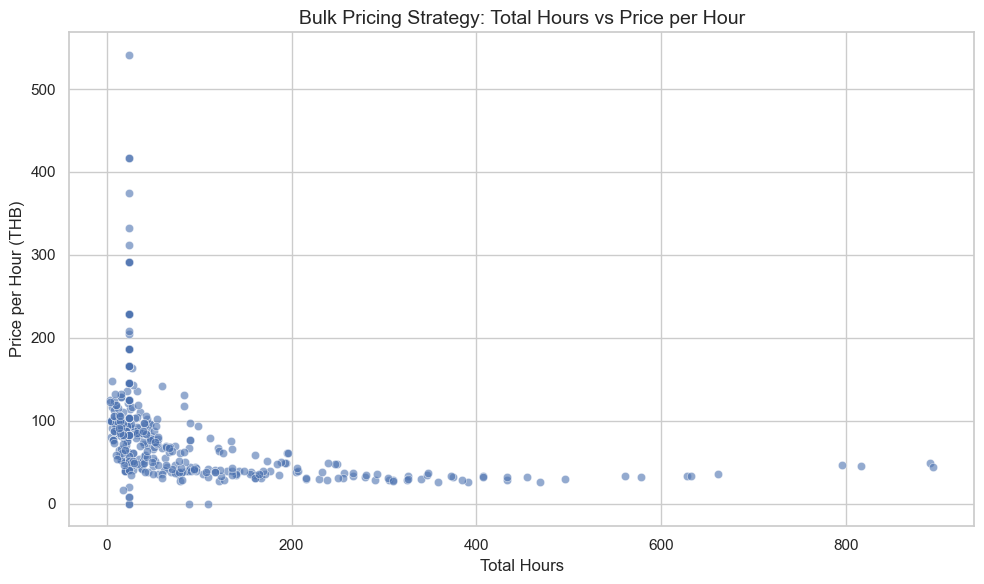

In [24]:
# 1. Scatter Plot: Total Hours vs Price per Hour
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='total_hours', y='price_per_hour', alpha=0.6, color='b')
plt.title('Bulk Pricing Strategy: Total Hours vs Price per Hour', fontsize=14)
plt.xlabel('Total Hours', fontsize=12)
plt.ylabel('Price per Hour (THB)', fontsize=12)
plt.tight_layout()
plt.savefig('scatter_hours_price.png')
plt.show()

กราฟแบบจุด (Scatter Plot) นี้แสดงความสัมพันธ์ระหว่าง "จำนวนชั่วโมงเรียน (แกนนอน)" และ "ราคาต่อชั่วโมง (แกนตั้ง)" * Insight: จะเห็นได้ชัดเจนว่ากลุ่มคอร์สที่ชั่วโมงเรียนน้อยๆ (กระจุกตัวทางซ้าย) จะมีราคาต่อชั่วโมงกระโดดไปสูงมาก บางคอร์สทะลุ 300-500 บาท/ชม. แต่พอชั่วโมงเรียนเริ่มแตะหลัก 100 ชั่วโมงขึ้นไป กราฟจะลู่ลงมาเกาะกลุ่มกันด้านล่างสุด (ราคาไม่ถึง 50 บาท/ชม.) นี่คือภาพสะท้อนของการจัดโปรโมชั่นมัดรวมคอร์สเพื่อจูงใจให้ผู้ปกครองซื้อก้อนใหญ่ครับ

C:\Users\jarun\AppData\Local\Temp\ipykernel_18944\277860302.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subject_price.values, y=subject_price.index, palette='viridis')


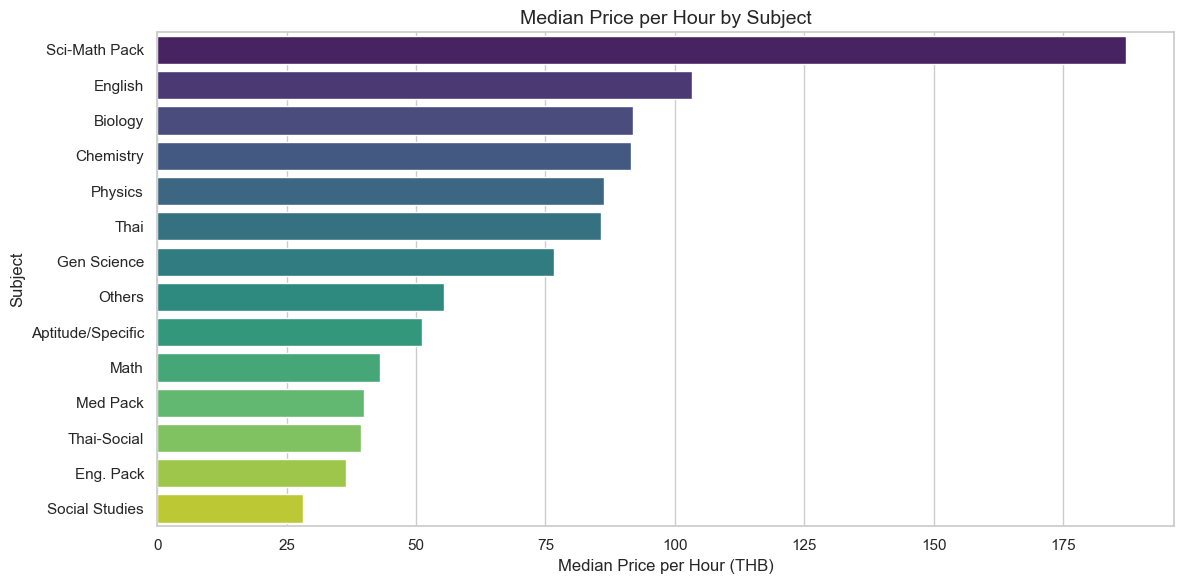

In [26]:
# 2. Bar Chart: Median Price per Hour by Subject
plt.figure(figsize=(12, 6))
subject_price = df.groupby('subject_eng')['price_per_hour'].median().sort_values(ascending=False)
sns.barplot(x=subject_price.values, y=subject_price.index, palette='viridis')
plt.title('Median Price per Hour by Subject', fontsize=14)
plt.xlabel('Median Price per Hour (THB)', fontsize=12)
plt.ylabel('Subject', fontsize=12)
plt.tight_layout()
plt.savefig('bar_price_by_subject.png')
plt.show()

กราฟแท่งแสดง "ราคาเฉลี่ยต่อชั่วโมง (ค่ามัธยฐาน)" แยกตามรายวิชา

Insight: กราฟนี้บอกขุมทรัพย์ทางธุรกิจครับ วิชาอย่าง English (ภาษาอังกฤษ), Biology (ชีวะ) และ Chemistry (เคมี) สามารถตั้งราคาต่อชั่วโมงได้สูงเกือบ 100 บาท ในขณะที่วิชาปราบเซียนยอดฮิตอย่าง Math (คณิตศาสตร์) กลับทำราคาได้ต่ำสุด (แท่งล่างสุด) สาเหตุเพราะการแข่งขันที่ดุเดือดจนเกิดสงครามราคานั่นเอง

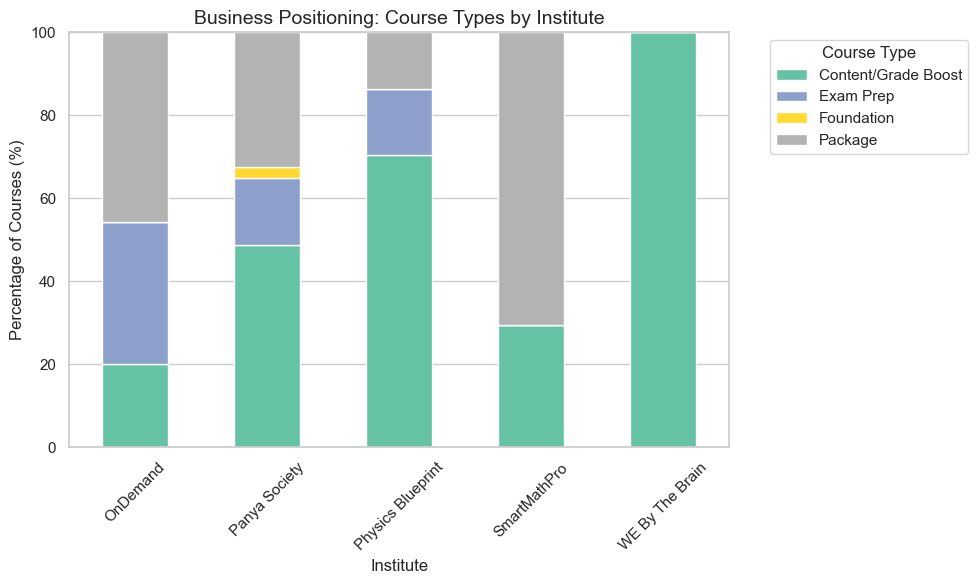

In [27]:
# 3. Stacked Bar Chart: Course Types by Institute
inst_type = pd.crosstab(df['institute_name'], df['course_type_eng'], normalize='index') * 100
inst_type.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
plt.title('Business Positioning: Course Types by Institute', fontsize=14)
plt.xlabel('Institute', fontsize=12)
plt.ylabel('Percentage of Courses (%)', fontsize=12)
plt.legend(title='Course Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('stacked_course_type.png')
plt.show()

กราฟแท่งแบบซ้อน (Stacked Bar) แสดง สัดส่วนประเภทคอร์ส ที่แต่ละสถาบันเน้นขาย

Insight: * ดูที่แท่งของ WE By The Brain: จะเป็นสีเขียว (Content/Grade Boost - ติวเนื้อหา) 100% เต็ม แปลว่าที่นี่เน้นขายคอร์สย่อยแก้ปัญหาเฉพาะจุด

- เทียบกับแท่งของ SmartMathPro: จะเป็นสีส้ม (Package - คอร์สเหมา) กินพื้นที่ไปกว่า 70% แปลว่าที่นี่เน้นขายความคุ้มค่า มัดรวมวิชาให้เด็กจบในที่เดียว

C:\Users\jarun\AppData\Local\Temp\ipykernel_18944\3589992620.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tutors.values, y=top_tutors.index, palette='magma')


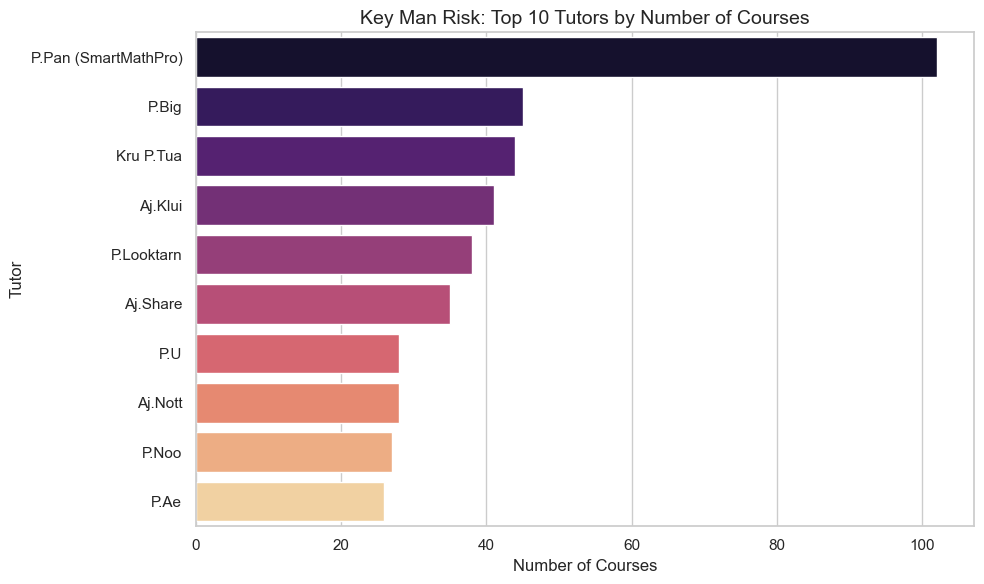

In [28]:
# 4. Bar Chart: Top 10 Tutors by Course Count
# Map top tutor names to english just for plotting
top_tutors = df_tutors['individual_tutor'].value_counts().head(10)
tutor_map = {
    'พี่ปั้น SmartMathPro': 'P.Pan (SmartMathPro)',
    'ดร.ณัฐชัย เก่งพิพัฒน์ (พี่บิ๊ก)': 'P.Big',
    'ครูพี่ตั้ว': 'Kru P.Tua',
    'อ.ขลุ่ย': 'Aj.Klui',
    'ดร.ธนัชพร วงศ์เวียน (พี่ลูกตาล)': 'P.Looktarn',
    'สุปิติ บูรณวัฒนาโชค (อ.แชร์)': 'Aj.Share',
    'อ.สุรเชษฐ์ พิชิตพงศ์เผ่า (พี่ยู)': 'P.U',
    'ธรรมนิติ์ พิพัฒน์ศรีสวัสดิ์ (อ.นอต)': 'Aj.Nott',
    'พี่หนู': 'P.Noo',
    'อ.วิเศษ กี่สุขพันธ์ (พี่เอ๋)': 'P.Ae'
}
top_tutors.index = top_tutors.index.map(tutor_map)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_tutors.values, y=top_tutors.index, palette='magma')
plt.title('Key Man Risk: Top 10 Tutors by Number of Courses', fontsize=14)
plt.xlabel('Number of Courses', fontsize=12)
plt.ylabel('Tutor', fontsize=12)
plt.tight_layout()
plt.savefig('bar_top_tutors.png')
plt.show()

Insight: กราฟนี้จะเห็นแท่งบนสุดของ P.Pan (พี่ปั้น SmartMathPro) พุ่งทะลุไปถึงกว่า 100 คอร์ส ทิ้งห่างติวเตอร์ท่านอื่นๆ อย่างเห็นได้ชัดเจน ในมุมธุรกิจ กราฟนี้เตือนเราว่าสถาบันกำลังฝากยอดขายจำนวนมหาศาลไว้กับคนๆ เดียว ซึ่งหากเกิดเหตุไม่คาดฝันกับติวเตอร์ท่านนี้ สถาบันจะต้องมีแผนสำรองที่รัดกุมมากครับ